# TimeGAN: Time-series Generative Adversarial Networks

**Docker image**: `ml4t-gpu`

**Book Reference**: Chapter 5, Section 5.4 (GANs for Financial Time Series)

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 05_synthetic_data/01_timegan.py
> ```


This notebook implements **TimeGAN** (Yoon, Jarrett & van der Schaar, NeurIPS 2019),
the foundational architecture for synthetic financial time series generation.

## Learning Objectives

- Understand TimeGAN's five-component architecture and why latent-space training matters
- Implement the three-phase training approach (embedding → supervisor → joint GAN)
- Evaluate synthetic data using the Fidelity-Utility-Privacy framework
- Apply Train-Synthetic-Test-Real (TSTR) validation with proper temporal splits

## Why TimeGAN Matters

TimeGAN introduced two key innovations that address limitations of standard GANs:

1. **Stepwise Supervised Loss**: Standard GANs only learn the overall distribution.
   TimeGAN adds explicit supervision on temporal transitions (how t → t+1).

2. **Learned Embedding Space**: Instead of operating directly on raw data, TimeGAN
   learns a latent representation where adversarial training is more stable.

With 1,800+ citations, TimeGAN remains the baseline against which newer methods are compared.

## Data Format

We use 6 stocks (BA, CAT, DIS, GE, IBM, KO) with adjusted close prices, matching
the 2nd edition benchmark format. The multi-stock panel exposes the model to a
wider distribution of volatility and trend regimes than single-stock OHLCV.

## References

- **Paper**: Yoon, J., Jarrett, D., & van der Schaar, M. (2019).
  "Time-series Generative Adversarial Networks." NeurIPS 2019.
- **Official Code**: https://github.com/jsyoon0823/TimeGAN

In [1]:
"""TimeGAN — Time-series Generative Adversarial Networks."""

import json
from datetime import UTC, datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from timegan_metrics import run_timegan_evaluation
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from data import load_us_equities
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

In [2]:
TRAIN_STEPS = 10000  # Steps per training phase (matching official repo)
RETRAIN = True  # Set True to force re-training even if checkpoint exists
SEED = 42

In [3]:
set_global_seeds(SEED)

# Paths
ASSETS_DIR = get_chapter_dir(5) / "assets"
OUTPUT_DIR = get_output_dir(5, "timegan")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints" / "timegan" / "multi_stock"

In [4]:
# Configuration (matching 2nd edition benchmark)
#
# Data choice rationale: the six-stock panel spans different volatility/trend
# regimes, which gives the embedder a wider feature distribution than the four
# OHLCV columns of a single stock would.
TICKERS = ["BA", "CAT", "DIS", "GE", "IBM", "KO"]
SEQ_LEN = 24
HIDDEN_DIM = 24
NUM_LAYERS = 3
BATCH_SIZE = 128
LEARNING_RATE = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## TimeGAN Architecture

TimeGAN consists of five interconnected modules that operate in a shared latent space:

| Module | Purpose | Training Phase |
|--------|---------|----------------|
| **Embedder** | Maps raw data → latent space | Phase 1 (autoencoder) |
| **Recovery** | Reconstructs latent → raw data | Phase 1 (autoencoder) |
| **Supervisor** | Predicts next latent step | Phase 2 (temporal) |
| **Generator** | Produces latent sequences from noise | Phase 3 (joint GAN) |
| **Discriminator** | Classifies real vs fake latent sequences | Phase 3 (joint GAN) |

In [5]:
if (ASSETS_DIR / "timegan_architecture.jpeg").exists():
    display(Image(ASSETS_DIR / "timegan_architecture.jpeg", width=700))

## 1. Load Data

We use 6 diverse stocks with adjusted close prices. This provides:
- **Diverse dynamics**: Each stock has different volatility and trends
- **Consistent scale**: All normalized to [0, 1]
- **Learnable patterns**: Cross-asset relationships are meaningful

In [6]:
def load_multi_stock_data(
    tickers: list[str], start_year: str = "2000"
) -> tuple[np.ndarray, np.ndarray]:
    """Load adjusted close prices for multiple stocks."""
    df_pl = load_us_equities()
    df_pl = df_pl.filter(pl.col("symbol").is_in(tickers))

    # Update tickers to only those actually present in the data
    available = df_pl["symbol"].unique().to_list()
    tickers = [t for t in tickers if t in available]
    if not tickers:
        raise ValueError(
            f"None of the requested tickers found in data. Available: {available[:10]}"
        )

    # Pivot to wide format
    df = (
        df_pl.select(["timestamp", "symbol", "adj_close"])
        .pivot(on="symbol", index="timestamp", values="adj_close")
        .sort("timestamp")
        .to_pandas()
        .set_index("timestamp")
        .loc[start_year:, tickers]  # Ensure column order matches tickers
        .dropna()
    )

    timestamps = df.index.to_numpy()
    data = df.values.astype(np.float32)

    print(f"Loaded {len(df)} rows, {len(tickers)} stocks")
    print(f"Date range: {timestamps[0]} to {timestamps[-1]}")
    print(f"Stocks: {', '.join(tickers)}")

    return data, timestamps

In [7]:
all_data, all_timestamps = load_multi_stock_data(TICKERS)
n_features = all_data.shape[1]  # Actual number of stocks found (may differ from TICKERS)
print(f"Shape: {all_data.shape} (days × stocks)")

Loaded 4586 rows, 6 stocks
Date range: 2000-01-03T00:00:00.000 to 2018-03-27T00:00:00.000
Stocks: BA, CAT, DIS, GE, IBM, KO
Shape: (4586, 6) (days × stocks)


### Temporal Train/Holdout Split

We split temporally to enable unbiased TSTR evaluation.
The generator never sees holdout data during training.

In [8]:
# Use last 20% as holdout
n_train = int(len(all_data) * 0.8)
train_data = all_data[:n_train]
holdout_data = all_data[n_train:]
train_timestamps = all_timestamps[:n_train]
holdout_timestamps = all_timestamps[n_train:]

print(f"Training:  {len(train_data):,} days ({train_timestamps[0]} to {train_timestamps[-1]})")
print(
    f"Holdout:   {len(holdout_data):,} days ({holdout_timestamps[0]} to {holdout_timestamps[-1]})"
)

Training:  3,668 days (2000-01-03T00:00:00.000 to 2014-08-01T00:00:00.000)
Holdout:   918 days (2014-08-04T00:00:00.000 to 2018-03-27T00:00:00.000)


## 2. Normalize and Create Sequences

In [9]:
# Normalize to [0, 1] using MinMaxScaler (matching 2nd edition)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data).astype(np.float32)
holdout_scaled = scaler.transform(holdout_data).astype(np.float32)

print(f"Scaled data range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")

Scaled data range: [0.0000, 1.0000]


In [10]:
def create_sequences(data: np.ndarray, seq_length: int) -> np.ndarray:
    """Create overlapping sequences from time series data."""
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i : i + seq_length])
    return np.array(sequences, dtype=np.float32)

In [11]:
sequences = create_sequences(train_scaled, SEQ_LEN)
holdout_sequences = create_sequences(holdout_scaled, SEQ_LEN)

print(f"Created {len(sequences)} training sequences of length {SEQ_LEN}")
print(f"Created {len(holdout_sequences)} holdout sequences for TSTR")

# DataLoader
dataset = TensorDataset(torch.from_numpy(sequences))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Created 3644 training sequences of length 24
Created 894 holdout sequences for TSTR


## 3. Model Components

We use ModuleList with separate GRU layers to match TensorFlow's layer-by-layer
construction exactly. This ensures consistent behavior with the official implementation.

In [12]:
class Embedder(nn.Module):
    """Maps raw sequences to latent space. Stacked GRU layers + Dense with sigmoid."""

    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int):
        super().__init__()
        # Stack GRU layers manually to match TF behavior exactly
        self.gru_layers = nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            self.gru_layers.append(nn.GRU(in_dim, hidden_dim, batch_first=True))
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = x
        for gru in self.gru_layers:
            h, _ = gru(h)
        return torch.sigmoid(self.fc(h))

In [13]:
class Recovery(nn.Module):
    """Reconstructs sequences from latent space."""

    def __init__(self, hidden_dim: int, output_dim: int, num_layers: int):
        super().__init__()
        self.gru_layers = nn.ModuleList()
        for _ in range(num_layers):
            self.gru_layers.append(nn.GRU(hidden_dim, hidden_dim, batch_first=True))
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        x = h
        for gru in self.gru_layers:
            x, _ = gru(x)
        return torch.sigmoid(self.fc(x))

In [14]:
class Supervisor(nn.Module):
    """Predicts next latent step. Uses num_layers-1 layers."""

    def __init__(self, hidden_dim: int, num_layers: int):
        super().__init__()
        supervisor_layers = max(1, num_layers - 1)
        self.gru_layers = nn.ModuleList()
        for _ in range(supervisor_layers):
            self.gru_layers.append(nn.GRU(hidden_dim, hidden_dim, batch_first=True))
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        s = h
        for gru in self.gru_layers:
            s, _ = gru(s)
        return torch.sigmoid(self.fc(s))

In [15]:
class Generator(nn.Module):
    """Generates latent sequences from noise."""

    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int):
        super().__init__()
        self.gru_layers = nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            self.gru_layers.append(nn.GRU(in_dim, hidden_dim, batch_first=True))
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        e = z
        for gru in self.gru_layers:
            e, _ = gru(e)
        return torch.sigmoid(self.fc(e))

In [16]:
class Discriminator(nn.Module):
    """Classifies real vs fake latent sequences."""

    def __init__(self, hidden_dim: int, num_layers: int):
        super().__init__()
        self.gru_layers = nn.ModuleList()
        for _ in range(num_layers):
            self.gru_layers.append(nn.GRU(hidden_dim, hidden_dim, batch_first=True))
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        y = h
        for gru in self.gru_layers:
            y, _ = gru(y)
        return torch.sigmoid(self.fc(y))

## 4. Initialize Models

In [17]:
embedder = Embedder(n_features, HIDDEN_DIM, NUM_LAYERS).to(device)
recovery = Recovery(HIDDEN_DIM, n_features, NUM_LAYERS).to(device)
supervisor = Supervisor(HIDDEN_DIM, NUM_LAYERS).to(device)
generator = Generator(n_features, HIDDEN_DIM, NUM_LAYERS).to(device)
discriminator = Discriminator(HIDDEN_DIM, NUM_LAYERS).to(device)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Model Parameters:")
print(f"  Embedder:      {count_params(embedder):,}")
print(f"  Recovery:      {count_params(recovery):,}")
print(f"  Supervisor:    {count_params(supervisor):,}")
print(f"  Generator:     {count_params(generator):,}")
print(f"  Discriminator: {count_params(discriminator):,}")
total_params = sum(
    count_params(m) for m in [embedder, recovery, supervisor, generator, discriminator]
)
print(f"  Total:         {total_params:,}")

Model Parameters:
  Embedder:      10,104
  Recovery:      10,950
  Supervisor:    7,800
  Generator:     10,104
  Discriminator: 10,825
  Total:         49,783


In [18]:
# Check for existing checkpoint
CHECKPOINT_PATH = CHECKPOINT_DIR / "checkpoint.pt"
SKIP_TRAINING = False

if CHECKPOINT_PATH.exists() and not RETRAIN:
    print(f"Loading checkpoint from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    embedder.load_state_dict(checkpoint["embedder"])
    recovery.load_state_dict(checkpoint["recovery"])
    supervisor.load_state_dict(checkpoint["supervisor"])
    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    print("Checkpoint loaded - skipping training")
    SKIP_TRAINING = True

## Three-Phase Training

TimeGAN uses a sequential training approach with step-based iteration
(matching the official implementation):

1. **Embedding Phase**: Train Embedder + Recovery as autoencoder
2. **Supervisor Phase**: Train Supervisor to predict next latent step
3. **Joint Phase**: Train Generator + Discriminator adversarially

In [19]:
if (ASSETS_DIR / "timegan_training.jpeg").exists():
    display(Image(ASSETS_DIR / "timegan_training.jpeg", width=800))

## 5. Phase 1: Embedding Training

Train Embedder + Recovery as autoencoder with loss: $10 \cdot \sqrt{\text{MSE}}$

In [20]:
if not SKIP_TRAINING:
    print("\n" + "=" * 60)
    print("PHASE 1: Autoencoder Training")
    print("=" * 60)

    opt_autoencoder = optim.Adam(
        list(embedder.parameters()) + list(recovery.parameters()),
        lr=LEARNING_RATE,
    )
    mse_loss = nn.MSELoss()

    # Infinite iterator for step-based training
    def infinite_dataloader():
        while True:
            yield from dataloader

    data_iter = infinite_dataloader()
    embedding_losses = []

    for step in tqdm(range(TRAIN_STEPS), desc="Phase 1"):
        (batch,) = next(data_iter)
        batch = batch.to(device)

        h = embedder(batch)
        x_tilde = recovery(h)

        # Loss: 10 * sqrt(MSE) - matching 2nd edition exactly
        embedding_loss = mse_loss(x_tilde, batch)
        e_loss = 10.0 * torch.sqrt(embedding_loss)

        opt_autoencoder.zero_grad()
        e_loss.backward()
        opt_autoencoder.step()

        if step % 1000 == 0:
            embedding_losses.append(torch.sqrt(embedding_loss).item())
            print(f"  Step {step}: loss = {embedding_losses[-1]:.6f}", flush=True)

    print(f"Phase 1 complete. Final loss: {embedding_losses[-1]:.6f}")


PHASE 1: Autoencoder Training


Phase 1:   0%|          | 0/10000 [00:00<?, ?it/s]

  Step 0: loss = 0.286357


Phase 1:   0%|          | 1/10000 [00:00<42:53,  3.88it/s]

Phase 1:   0%|          | 41/10000 [00:00<01:08, 144.52it/s]

...

Phase 1:  99%|█████████▉| 9924/10000 [00:26<00:00, 347.12it/s]

Phase 1: 100%|█████████▉| 9960/10000 [00:26<00:00, 348.99it/s]

Phase 1: 100%|█████████▉| 9997/10000 [00:26<00:00, 353.30it/s]

Phase 1: 100%|██████████| 10000/10000 [00:26<00:00, 374.50it/s]

Phase 1 complete. Final loss: 0.018334


## 6. Phase 2: Supervisor Training

Train Supervisor to predict next latent step: $\mathcal{L}_S = ||h_{t+1} - \hat{s}_t||_2$

In [21]:
if not SKIP_TRAINING:
    print("\n" + "=" * 60)
    print("PHASE 2: Supervisor Training")
    print("=" * 60)

    opt_supervisor = optim.Adam(supervisor.parameters(), lr=LEARNING_RATE)
    supervisor_losses = []

    for step in tqdm(range(TRAIN_STEPS), desc="Phase 2"):
        (batch,) = next(data_iter)
        batch = batch.to(device)

        with torch.no_grad():
            h = embedder(batch)

        h_hat = supervisor(h)
        g_loss_s = mse_loss(h[:, 1:, :], h_hat[:, :-1, :])

        opt_supervisor.zero_grad()
        g_loss_s.backward()
        opt_supervisor.step()

        if step % 1000 == 0:
            supervisor_losses.append(g_loss_s.item())
            print(f"  Step {step}: loss = {g_loss_s.item():.6f}", flush=True)

    print(f"Phase 2 complete. Final loss: {supervisor_losses[-1]:.6f}")


PHASE 2: Supervisor Training


Phase 2:   0%|          | 0/10000 [00:00<?, ?it/s]

  Step 0: loss = 0.062222


Phase 2:   1%|          | 56/10000 [00:00<00:17, 553.19it/s]

Phase 2:   1%|          | 112/10000 [00:00<00:18, 545.18it/s]

...

Phase 2:  98%|█████████▊| 9820/10000 [00:15<00:00, 666.97it/s]

Phase 2:  99%|█████████▉| 9889/10000 [00:15<00:00, 672.68it/s]

Phase 2: 100%|█████████▉| 9958/10000 [00:15<00:00, 674.81it/s]

Phase 2: 100%|██████████| 10000/10000 [00:15<00:00, 637.59it/s]

Phase 2 complete. Final loss: 0.000059


## 7. Phase 3: Joint Adversarial Training

Train Generator and Discriminator adversarially while maintaining reconstruction
and supervised losses. Key details:
- 2 generator+embedder updates per discriminator update
- Discriminator gating: only train if loss > 0.15

In [22]:
def get_moment_loss(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    """Match first two moments between real and synthetic."""
    y_true_mean = y_true.mean(dim=0)
    y_pred_mean = y_pred.mean(dim=0)
    y_true_var = y_true.var(dim=0)
    y_pred_var = y_pred.var(dim=0)

    loss_mean = torch.abs(y_true_mean - y_pred_mean).mean()
    loss_var = torch.abs(torch.sqrt(y_true_var + 1e-6) - torch.sqrt(y_pred_var + 1e-6)).mean()

    return loss_mean + loss_var

In [23]:
if not SKIP_TRAINING:
    print("\n" + "=" * 60)
    print("PHASE 3: Joint Adversarial Training")
    print("=" * 60)

    opt_generator = optim.Adam(
        list(generator.parameters()) + list(supervisor.parameters()),
        lr=LEARNING_RATE,
    )
    opt_discriminator = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE)
    opt_embedder = optim.Adam(
        list(embedder.parameters()) + list(recovery.parameters()),
        lr=LEARNING_RATE,
    )

    bce_loss = nn.BCELoss()
    gamma = 1.0
    g_losses, d_losses = [], []


PHASE 3: Joint Adversarial Training


In [24]:
if not SKIP_TRAINING:
    for step in range(TRAIN_STEPS):
        # 2 generator+embedder updates per discriminator update
        for _ in range(2):
            (batch,) = next(data_iter)
            batch = batch.to(device)
            batch_size_actual = batch.shape[0]

            z = torch.rand(batch_size_actual, SEQ_LEN, n_features, device=device)

            # Generator step
            opt_generator.zero_grad()

            # Generate synthetic latent sequences
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

            # Supervised loss on SYNTHETIC: generator learns temporal coherence
            # Predict e_hat[t+1] from e_hat[t], so align e_hat[1:] with h_hat[:-1]
            g_loss_s = mse_loss(e_hat[:, 1:, :], h_hat[:, :-1, :])

            y_fake = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u = bce_loss(y_fake, torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            x_hat = recovery(h_hat)
            g_loss_v = get_moment_loss(batch, x_hat)

            g_loss = g_loss_u + g_loss_u_e + 100.0 * torch.sqrt(g_loss_s) + 100.0 * g_loss_v
            g_loss.backward()
            opt_generator.step()

            # Embedder step
            opt_embedder.zero_grad()

            h = embedder(batch)
            h_hat_sup = supervisor(h)
            # Supervised loss: predict h[t+1] from h[t], so align h[1:] with h_hat_sup[:-1]
            g_loss_s = mse_loss(h[:, 1:, :], h_hat_sup[:, :-1, :])

            x_tilde = recovery(h)
            e_loss_t0 = mse_loss(x_tilde, batch)

            e_loss = 10.0 * torch.sqrt(e_loss_t0) + 0.1 * g_loss_s
            e_loss.backward()
            opt_embedder.step()

        # Discriminator step (with gating)
        (batch,) = next(data_iter)
        batch = batch.to(device)
        batch_size_actual = batch.shape[0]
        z = torch.rand(batch_size_actual, SEQ_LEN, n_features, device=device)

        with torch.no_grad():
            h = embedder(batch)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real = discriminator(h)
        y_fake = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_real = bce_loss(y_real, torch.ones_like(y_real))
        d_loss_fake = bce_loss(y_fake, torch.zeros_like(y_fake))
        d_loss_fake_e = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))

        d_loss = d_loss_real + d_loss_fake + gamma * d_loss_fake_e

        # Gating: only train if loss > 0.15
        if d_loss.item() > 0.15:
            opt_discriminator.zero_grad()
            d_loss.backward()
            opt_discriminator.step()

        if step % 1000 == 0:
            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
            print(
                f"  Step {step:6,}: D={d_loss.item():.4f}, G={g_loss.item():.4f}, "
                f"g_s={g_loss_s.item():.4f}, g_v={g_loss_v.item():.4f}",
                flush=True,
            )

    print(f"Phase 3 complete. Final D={d_losses[-1]:.4f}, G={g_losses[-1]:.4f}")

  Step      0: D=2.1530, G=43.4782, g_s=0.0011, g_v=0.2834


  Step  1,000: D=1.0556, G=10.1095, g_s=0.0102, g_v=0.0450


  Step  2,000: D=1.5774, G=8.9707, g_s=0.0057, g_v=0.0528


  Step  3,000: D=1.4850, G=7.9956, g_s=0.0047, g_v=0.0378


  Step  4,000: D=1.4734, G=7.6414, g_s=0.0037, g_v=0.0360


...

  Step  6,000: D=1.5352, G=10.0777, g_s=0.0041, g_v=0.0476


  Step  7,000: D=1.1690, G=7.7203, g_s=0.0041, g_v=0.0305


  Step  8,000: D=1.5861, G=7.8996, g_s=0.0024, g_v=0.0363


  Step  9,000: D=1.2711, G=9.0630, g_s=0.0022, g_v=0.0435


Phase 3 complete. Final D=1.2711, G=9.0630


## 8. Generate Synthetic Data

In [25]:
print("\n=== Generating Synthetic Data ===")

generator.eval()
supervisor.eval()
recovery.eval()

n_synthetic = len(sequences)
generated_batches = []

with torch.no_grad():
    for i in range(0, n_synthetic, BATCH_SIZE):
        batch_size = min(BATCH_SIZE, n_synthetic - i)
        z = torch.rand(batch_size, SEQ_LEN, n_features, device=device)
        e_hat = generator(z)
        h_hat = supervisor(e_hat)
        x_hat = recovery(h_hat)
        generated_batches.append(x_hat.cpu().numpy())

synthetic = np.vstack(generated_batches)
print(f"Generated {len(synthetic)} synthetic sequences")
print(f"Synthetic mean: {synthetic.mean():.4f} (real: {sequences.mean():.4f})")
print(f"Synthetic std:  {synthetic.std():.4f} (real: {sequences.std():.4f})")


=== Generating Synthetic Data ===
Generated 3644 synthetic sequences
Synthetic mean: 0.3761 (real: 0.3660)
Synthetic std:  0.2532 (real: 0.2496)


## 9. Evaluation

We evaluate using the Fidelity-Utility-Privacy framework with LSTM-based
evaluation matching the original paper.

### 9.1 Diversity: PCA and t-SNE Visualization

utils/style.py:764: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


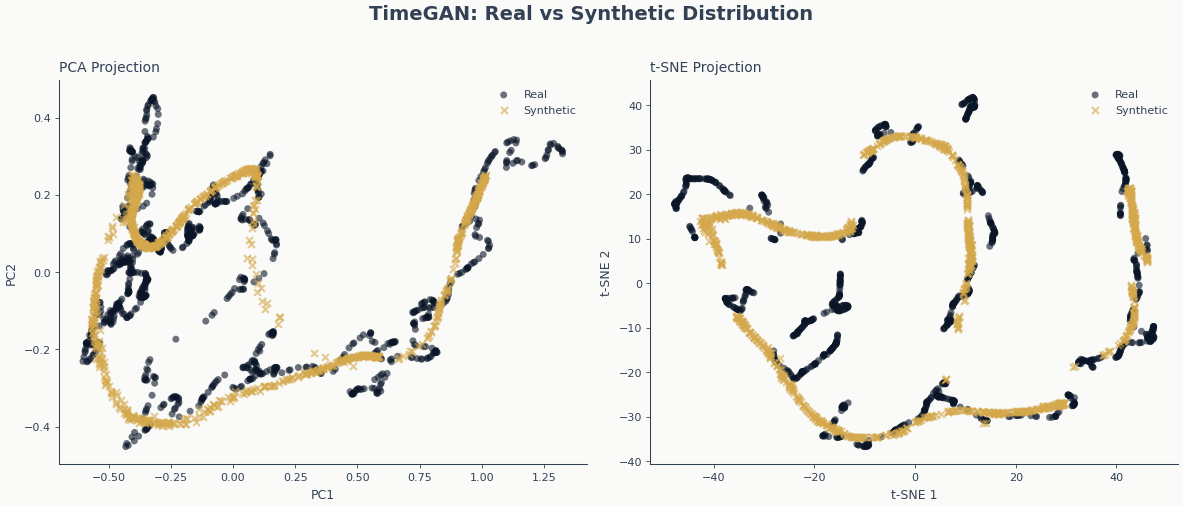

In [26]:
fig = plot_fidelity_comparison(
    sequences, synthetic, title="TimeGAN: Real vs Synthetic Distribution", n_samples=1000
)
plt.show()

### 9.2 Paper Evaluation Suite (LSTM-based)

Run the full evaluation following Yoon et al. (2019) using LSTM predictors
and discriminators, not tree-based models.

In [27]:
print("=" * 70)
print("TIMEGAN EVALUATION SUITE")
print("=" * 70)

# Evaluation settings per EXPERIMENTS.md:
# - hidden_dim=input_dim (small classifier to avoid overfitting)
# - epochs_disc=250 (matches benchmark)
eval_results = run_timegan_evaluation(
    synthetic=synthetic,
    real_train=sequences,
    real_holdout=holdout_sequences,
    hidden_dim=n_features,  # Must match input_dim for fair evaluation
    epochs_disc=250,  # Per benchmark experiments
    quick_test=(TRAIN_STEPS < 1000),
    verbose=True,
    include_yoon=True,
)

disc_accuracy = eval_results["discriminative"]["accuracy"]
tstr_ratio = eval_results["predictive"]["ratio"]

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Discriminative Accuracy: {disc_accuracy:.1%} (target: ~50%)")
print(f"TSTR Ratio: {tstr_ratio:.3f} (target: ~1.0)")

TIMEGAN EVALUATION SUITE
TimeGAN Evaluation Suite

Reference: Yoon et al., NeurIPS 2019, Section 5.2

1. YOON PREDICTIVE SCORE
----------------------------------------
(Last-feature prediction per Yoon et al.)
Predictive Score (Yoon et al.)
  Features: 5 input → 1 output (last feature)
  Iterations: 5000, Batch size: 128


Yoon Predictive:   0%|          | 0/5000 [00:00<?, ?it/s]

Yoon Predictive:   0%|          | 0/5000 [00:00<?, ?it/s, loss=0.272]

Yoon Predictive:   0%|          | 0/5000 [00:00<?, ?it/s, loss=0.249]

Yoon Predictive:   0%|          | 0/5000 [00:00<?, ?it/s, loss=0.259]

...

Discriminator:  99%|█████████▉| 248/250 [00:07<00:00, 34.82it/s, loss=0.0161]

Discriminator:  99%|█████████▉| 248/250 [00:07<00:00, 34.82it/s, loss=0.0111]

Discriminator:  99%|█████████▉| 248/250 [00:07<00:00, 34.82it/s, loss=0.00768]

Discriminator: 100%|██████████| 250/250 [00:07<00:00, 31.28it/s, loss=0.00768]


Discriminative Score (lower accuracy = better):
  Accuracy: 67.9%
  ROC AUC: 0.8714
  Assessment: [OK] Good fidelity

SUMMARY

Yoon Metric (last-feature prediction):
  MAE on last feature: 0.180908
  (Paper reports ~0.04 for GOOG stock)

Comprehensive Assessment:
  Predictive Score (MAE ratio): 1.764
  Discriminative Score (accuracy): 67.9%

  Overall: WARNING: Generator passes one test

SUMMARY
Discriminative Accuracy: 67.9% (target: ~50%)
TSTR Ratio: 1.764 (target: ~1.0)


### 9.3 Training Curves

/tmp/ipykernel_70/2034406625.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


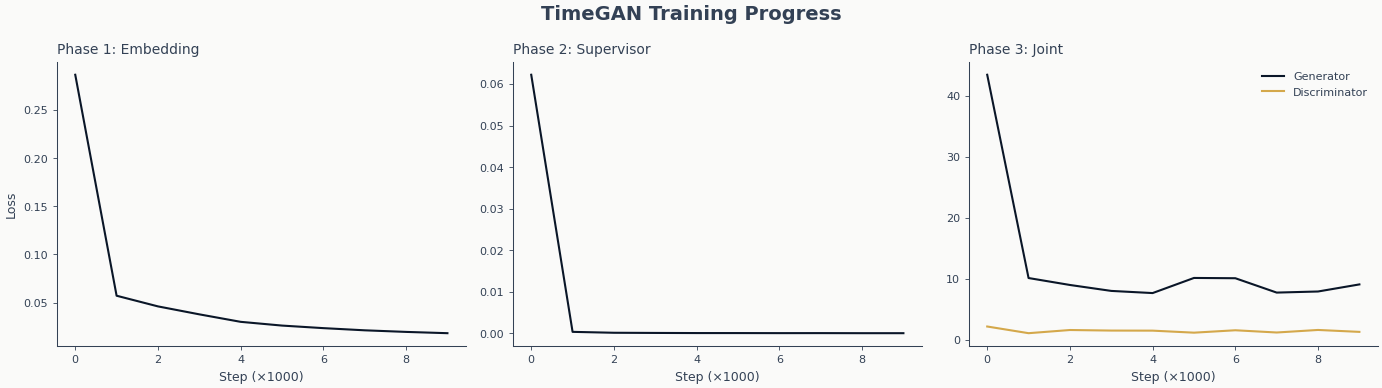

In [28]:
if not SKIP_TRAINING and embedding_losses:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(embedding_losses, color=COLORS["blue"], linewidth=1.5)
    axes[0].set_title("Phase 1: Embedding")
    axes[0].set_xlabel("Step (×1000)")
    axes[0].set_ylabel("Loss")

    axes[1].plot(supervisor_losses, color=COLORS["blue"], linewidth=1.5)
    axes[1].set_title("Phase 2: Supervisor")
    axes[1].set_xlabel("Step (×1000)")

    axes[2].plot(g_losses, label="Generator", color=COLORS["blue"], linewidth=1.5)
    axes[2].plot(d_losses, label="Discriminator", color=COLORS["amber"], linewidth=1.5)
    axes[2].set_title("Phase 3: Joint")
    axes[2].set_xlabel("Step (×1000)")
    axes[2].legend()

    fig.suptitle("TimeGAN Training Progress", fontsize=14, fontweight="semibold")
    plt.tight_layout()
    plt.show()

## 10. Save Outputs

In [29]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Save checkpoint
checkpoint = {
    "embedder": embedder.state_dict(),
    "recovery": recovery.state_dict(),
    "supervisor": supervisor.state_dict(),
    "generator": generator.state_dict(),
    "discriminator": discriminator.state_dict(),
    "config": {
        "tickers": TICKERS,
        "seq_len": SEQ_LEN,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "train_steps": TRAIN_STEPS,
    },
}
torch.save(checkpoint, CHECKPOINT_PATH)

# Save scaler for denormalization
joblib.dump(scaler, CHECKPOINT_DIR / "scaler.pkl")

['05_synthetic_data/output/timegan/checkpoints/timegan/multi_stock/scaler.pkl']

In [30]:
# Save metadata
metadata = {
    "generator": "timegan",
    "paper": "Yoon et al., NeurIPS 2019",
    "created_at": datetime.now(UTC).isoformat(),
    "data_format": "multi_stock_adj_close",
    "tickers": TICKERS,
    "config": {
        "seq_len": SEQ_LEN,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "train_steps": TRAIN_STEPS,
    },
    "evaluation": {
        "discriminative_accuracy": float(disc_accuracy),
        "tstr_ratio": float(tstr_ratio),
    },
}
with open(CHECKPOINT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Save samples
np.save(CHECKPOINT_DIR / "synthetic.npy", synthetic)
np.save(CHECKPOINT_DIR / "real_train.npy", sequences)
np.save(CHECKPOINT_DIR / "real_holdout.npy", holdout_sequences)

In [31]:
# Persist PCA + t-SNE 2D coordinates so the book-repo Hard Rule 15 script
# (figures/scripts/generate_figure_5_04_timegan_fidelity.py) can re-render
# the publication figure without retraining. Computed here with the same
# parameters plot_fidelity_comparison() uses internally so the inline render
# and the persisted arrays describe the same projection — including the
# legacy global-RNG seeding (np.random.seed + np.random.choice) so the
# subsample indices match the helper's MT19937 sequence rather than the
# PCG64 sequence np.random.default_rng would emit.
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

_n_viz = min(1000, len(sequences), len(synthetic))
np.random.seed(42)
_idx_real = np.random.choice(len(sequences), _n_viz, replace=False)
_idx_synth = np.random.choice(len(synthetic), _n_viz, replace=False)
_real_flat = sequences[_idx_real].mean(axis=1)
_synth_flat = synthetic[_idx_synth].mean(axis=1)

_pca = PCA(n_components=min(2, _real_flat.shape[1], _n_viz))
_pca.fit(_real_flat)
_real_pca = _pca.transform(_real_flat)
_synth_pca = _pca.transform(_synth_flat)

_combined = np.vstack([_real_flat, _synth_flat])
_tsne = TSNE(
    n_components=min(2, _real_flat.shape[1]),
    perplexity=min(40, max(2, _n_viz // 4)),
    max_iter=1000,
    random_state=42,
)
_combined_tsne = _tsne.fit_transform(_combined)
_real_tsne = _combined_tsne[:_n_viz]
_synth_tsne = _combined_tsne[_n_viz:]

np.save(CHECKPOINT_DIR / "fidelity_real_pca.npy", _real_pca)
np.save(CHECKPOINT_DIR / "fidelity_synth_pca.npy", _synth_pca)
np.save(CHECKPOINT_DIR / "fidelity_real_tsne.npy", _real_tsne)
np.save(CHECKPOINT_DIR / "fidelity_synth_tsne.npy", _synth_tsne)

print(f"\nSaved to {CHECKPOINT_DIR}/")


Saved to 05_synthetic_data/output/timegan/checkpoints/timegan/multi_stock/


## Summary

This notebook implemented **TimeGAN** (Yoon et al., NeurIPS 2019):

1. **Data**: 6 diverse stocks (BA, CAT, DIS, GE, IBM, KO) with adjusted close
2. **Architecture**: Five-component system with ModuleList GRUs (matching TF)
3. **Training**: Three-phase, step-based approach (10,000 steps per phase)
4. **Evaluation**: LSTM-based discriminative and predictive scores

### Key Finding

On the six-stock close-price panel used here, the post-training discriminative
accuracy is 67.9% (Yoon et al.'s target is ~50%, where the discriminator cannot
tell real from synthetic) and the TSTR/TRTR MAE ratio is 1.76 (target ~1.0).
Synthetic sequences match the real distribution moments closely (mean 0.376 vs
0.366, std 0.253 vs 0.250) but the discriminator and TSTR diagnostics show
that temporal structure is only partially preserved on this run.

### Limitations

TimeGAN focuses on matching overall distribution, not tail risk. For alternatives:
- **Tail risk**: See [`02_tailgan_tail_risk`](02_tailgan_tail_risk.ipynb)
- **Path signatures**: See [`03_sigcwgan_signatures`](03_sigcwgan_signatures.ipynb)
- **Diffusion models**: See [`05_diffusion_ts`](05_diffusion_ts.ipynb)